# Results Visualisation — LLM Toxic Comment Classification

In [45]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
LABELS = ["toxic", "severe_toxic", "obscene", "threat", "insult", "identity_hate"]
MODES  = ["zero_shot", "few_shot_5", "few_shot_10", "few_shot_5_synth", "few_shot_10_synth"]
MODE_LABELS = ["Zero-Shot", "Few-Shot-5", "Few-Shot-10", "Few-Shot-5-Synth", "Few-Shot-10-Synth"]

FIG_DIR = "figures"
os.makedirs(FIG_DIR, exist_ok=True)
print(f"Figures will be saved to: {FIG_DIR}/")

Figures will be saved to: figures/


In [46]:
df = pd.read_csv("results/evaluation_summary.csv")

llm_models = ["gpt-4.1", "gpt-4.1-mini", "gpt-5.4"]
ft_models  = ["toxic-bert", "unbiased-toxic-roberta"]
ft_names   = {"toxic-bert": "toxic-bert", "unbiased-toxic-roberta": "unbiased-toxic-roberta"}
ft_colors  = ["#e74c3c", "#c0392b"]

llm = df[df["model"].isin(llm_models)].copy()
ft  = df[df["model"].isin(ft_models)].copy()

print(f"LLM rows       : {len(llm)}")
print(f"Fine-tuned rows: {len(ft)}")
llm.head()

LLM rows       : 15
Fine-tuned rows: 2


,model,mode,exact_match_accuracy,micro_precision,micro_recall,micro_f1,macro_f1,toxic_precision,toxic_recall,toxic_f1,...,obscene_f1,threat_precision,threat_recall,threat_f1,insult_precision,insult_recall,insult_f1,identity_hate_precision,identity_hate_recall,identity_hate_f1
0,gpt-4.1-mini,few_shot_10,0.5778,0.687585,0.779924,0.730850,0.627598,0.891021,0.742974,0.810291,...,0.744788,0.328829,0.895706,0.481054,0.598702,0.901194,0.719445,0.475196,0.941379,0.631579
1,gpt-4.1-mini,few_shot_10_synth,0.5633,0.656166,0.838829,0.736338,0.623991,0.875212,0.845949,0.860332,...,0.757204,0.352151,0.803681,0.489720,0.577320,0.912052,0.707071,0.479964,0.908621,0.628129
2,gpt-4.1-mini,few_shot_5,0.5939,0.718966,0.802679,0.758520,0.613913,0.862721,0.861128,0.861924,...,0.739363,0.357724,0.809816,0.496241,0.599950,0.876583,0.712353,0.508604,0.917241,0.654367
3,gpt-4.1-mini,few_shot_5_synth,0.5811,0.684108,0.817276,0.744787,0.638281,0.867208,0.833231,0.849880,...,0.742085,0.380952,0.834356,0.523077,0.584950,0.905899,0.710878,0.507493,0.875862,0.642631
4,gpt-4.1-mini,zero_shot,0.5679,0.677380,0.812554,0.738835,0.615399,0.855889,0.800410,0.827221,...,0.761656,0.341709,0.834356,0.484848,0.550053,0.940644,0.694177,0.456467,0.931034,0.612592


## 1. Micro F1 by Model × Prompting Mode

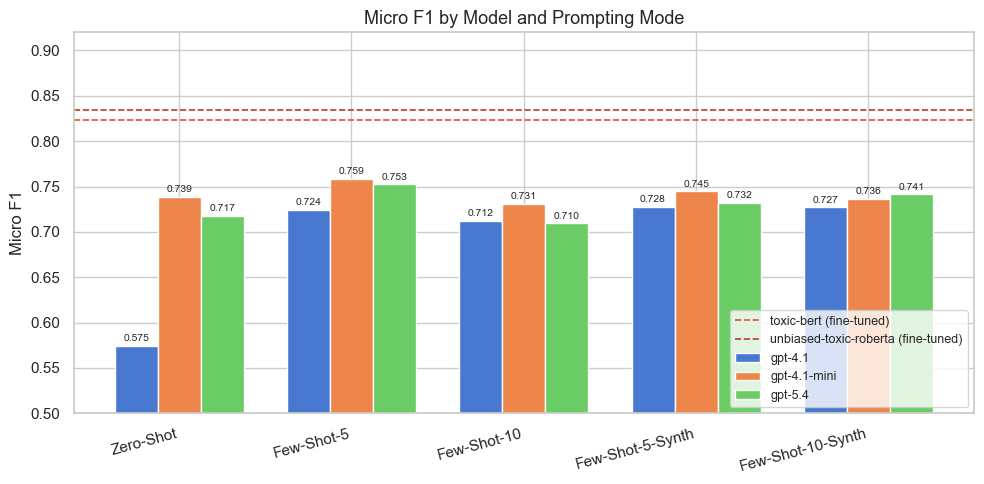

In [47]:
pivot = llm.pivot(index="mode", columns="model", values="micro_f1").reindex(MODES)
pivot.index = MODE_LABELS

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(MODES))
width = 0.25
colors = sns.color_palette("muted", 3)

for i, (model, color) in enumerate(zip(llm_models, colors)):
    vals = pivot[model].values
    bars = ax.bar(x + (i - 1) * width, vals, width, label=model, color=color)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.003,
                f"{v:.3f}", ha="center", va="bottom", fontsize=7.5)

# Fine-tuned baselines as horizontal lines
ft_colors = ["#e74c3c", "#c0392b"]
ft_names  = {"original": "toxic-bert", "unbiased": "unbiased-toxic-roberta"}
for (_, row), color in zip(ft.iterrows(), ft_colors):
    ax.axhline(row["micro_f1"], linestyle="--", color=color, linewidth=1.2,
               label=f"{ft_names.get(row['model'], row['model'])} (fine-tuned)")

ax.set_xticks(x)
ax.set_xticklabels(MODE_LABELS, rotation=15, ha="right")
ax.set_ylabel("Micro F1")
ax.set_title("Micro F1 by Model and Prompting Mode", fontsize=13)
ax.set_ylim(0.5, 0.92)
ax.legend(loc="lower right", fontsize=9)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/micro_f1_by_mode.png", dpi=150)
plt.show()

## 2. Precision vs Recall — All Models and Modes

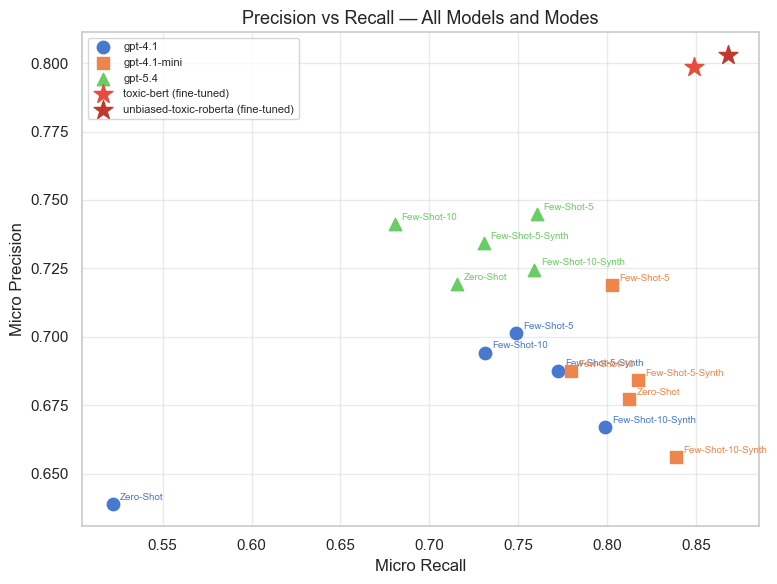

In [48]:
fig, ax = plt.subplots(figsize=(8, 6))
markers = ["o", "s", "^"]
colors  = sns.color_palette("muted", 3)

for model, marker, color in zip(llm_models, markers, colors):
    sub = llm[llm["model"] == model]
    for _, row in sub.iterrows():
        mode_label = MODE_LABELS[MODES.index(row["mode"])]
        ax.scatter(row["micro_recall"], row["micro_precision"],
                   marker=marker, color=color, s=80, zorder=3)
        ax.annotate(mode_label, (row["micro_recall"], row["micro_precision"]),
                    textcoords="offset points", xytext=(5, 3), fontsize=7, color=color)

# Legend for models
for model, marker, color in zip(llm_models, markers, colors):
    ax.scatter([], [], marker=marker, color=color, label=model, s=80)

# Fine-tuned baselines
for (_, row), color in zip(ft.iterrows(), ft_colors):
    name = ft_names.get(row["model"], row["model"])
    ax.scatter(row["micro_recall"], row["micro_precision"],
               marker="*", color=color, s=200, zorder=4, label=f"{name} (fine-tuned)")

ax.set_xlabel("Micro Recall")
ax.set_ylabel("Micro Precision")
ax.set_title("Precision vs Recall — All Models and Modes", fontsize=13)
ax.legend(fontsize=8, loc="upper left")
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/precision_recall.png", dpi=150)
plt.show()

## 3. Per-label F1 Heatmap (best mode per LLM + fine-tuned)

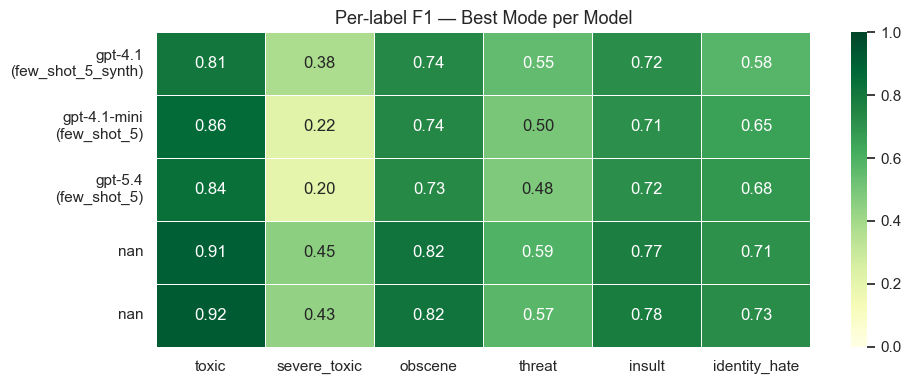

In [49]:
# Best mode per LLM model (by micro_f1)
best_llm = llm.loc[llm.groupby("model")["micro_f1"].idxmax()].copy()
best_llm["label"] = best_llm.apply(lambda r: f"{r['model']}\n({r['mode']})", axis=1)

ft_display = ft.copy()
ft_display["label"] = ft_display["model"].map(ft_names)

combined = pd.concat([best_llm, ft_display], ignore_index=True)

f1_cols = [f"{l}_f1" for l in LABELS]
heatmap_data = combined.set_index("label")[f1_cols].rename(
    columns={f"{l}_f1": l for l in LABELS}
)

fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(heatmap_data, annot=True, fmt=".2f", cmap="YlGn",
            vmin=0, vmax=1, linewidths=0.5, ax=ax)
ax.set_title("Per-label F1 — Best Mode per Model", fontsize=13)
ax.set_ylabel("")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/perlabel_f1_heatmap.png", dpi=150)
plt.show()

## 4. Zero-shot vs Best Few-shot (gpt-4.1 baseline)

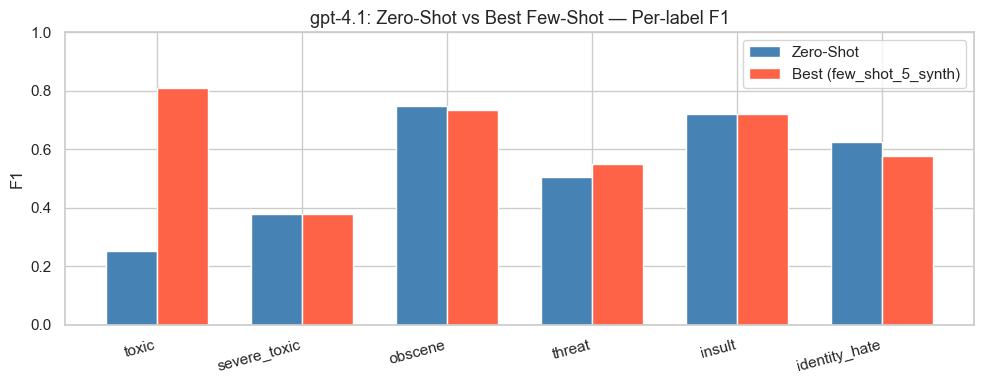

In [50]:
gpt41 = llm[llm["model"] == "gpt-4.1"].set_index("mode")

f1_cols   = [f"{l}_f1" for l in LABELS]
zero      = gpt41.loc["zero_shot", f1_cols].values
best_mode = gpt41["micro_f1"].idxmax()
best      = gpt41.loc[best_mode, f1_cols].values

x = np.arange(len(LABELS))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(x - width/2, zero, width, label="Zero-Shot",  color="steelblue")
ax.bar(x + width/2, best, width, label=f"Best ({best_mode})", color="tomato")
ax.set_xticks(x)
ax.set_xticklabels(LABELS, rotation=15, ha="right")
ax.set_ylabel("F1")
ax.set_ylim(0, 1)
ax.set_title("gpt-4.1: Zero-Shot vs Best Few-Shot — Per-label F1", fontsize=13)
ax.legend()
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/zeroshot_vs_fewshot.png", dpi=150)
plt.show()

## 5. LLM Best vs Fine-tuned — Per-label F1

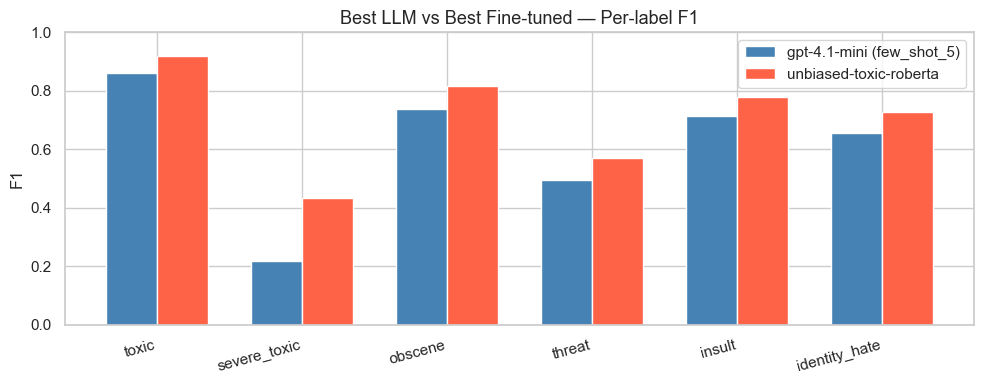

In [51]:
# Best LLM overall
best_llm_row = llm.loc[llm["micro_f1"].idxmax()]
best_llm_label = f"{best_llm_row['model']} ({best_llm_row['mode']})"

# Best fine-tuned
best_ft_row = ft.loc[ft["micro_f1"].idxmax()]
best_ft_label = ft_names.get(best_ft_row["model"], best_ft_row["model"])

llm_f1 = best_llm_row[[f"{l}_f1" for l in LABELS]].values
ft_f1  = best_ft_row[[f"{l}_f1" for l in LABELS]].values

x = np.arange(len(LABELS))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(x - width/2, llm_f1, width, label=best_llm_label, color="steelblue")
ax.bar(x + width/2, ft_f1,  width, label=best_ft_label,  color="tomato")
ax.set_xticks(x)
ax.set_xticklabels(LABELS, rotation=15, ha="right")
ax.set_ylabel("F1")
ax.set_ylim(0, 1)
ax.set_title("Best LLM vs Best Fine-tuned — Per-label F1", fontsize=13)
ax.legend()
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/llm_vs_finetuned.png", dpi=150)
plt.show()

## 6. Estimated API Cost (10,000 samples)

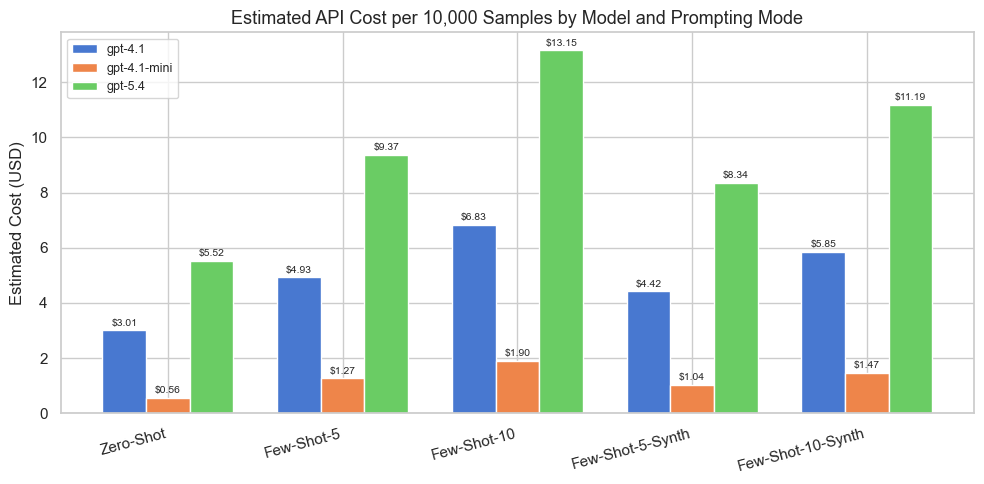

In [52]:
# Estimated API cost data (USD) from OpenAI list prices, Mar 2026
# gpt-4.1: $1.25/$10.00 per 1M tokens in/out
# gpt-4.1-mini: $0.40/$1.60 per 1M tokens in/out
# gpt-5.4: $2.50/$15.00 per 1M tokens in/out
cost_data = {
    "gpt-4.1":      [3.01, 4.93, 6.83, 4.42, 5.85],
    "gpt-4.1-mini": [0.56, 1.27, 1.90, 1.04, 1.47],
    "gpt-5.4":      [5.52, 9.37, 13.15, 8.34, 11.19],
}
cost_df = pd.DataFrame(cost_data, index=MODES)
cost_df.index = MODE_LABELS

# --- Chart 1: Cost by model × mode ---
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(MODES))
width = 0.25
colors = sns.color_palette("muted", 3)

for i, (model, color) in enumerate(zip(llm_models, colors)):
    vals = cost_df[model].values
    bars = ax.bar(x + (i - 1) * width, vals, width, label=model, color=color)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.1,
                f"${v:.2f}", ha="center", va="bottom", fontsize=7.5)

ax.set_xticks(x)
ax.set_xticklabels(MODE_LABELS, rotation=15, ha="right")
ax.set_ylabel("Estimated Cost (USD)")
ax.set_title("Estimated API Cost per 10,000 Samples by Model and Prompting Mode", fontsize=13)
ax.legend(loc="upper left", fontsize=9)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/api_cost_by_mode.png", dpi=150)
plt.show()

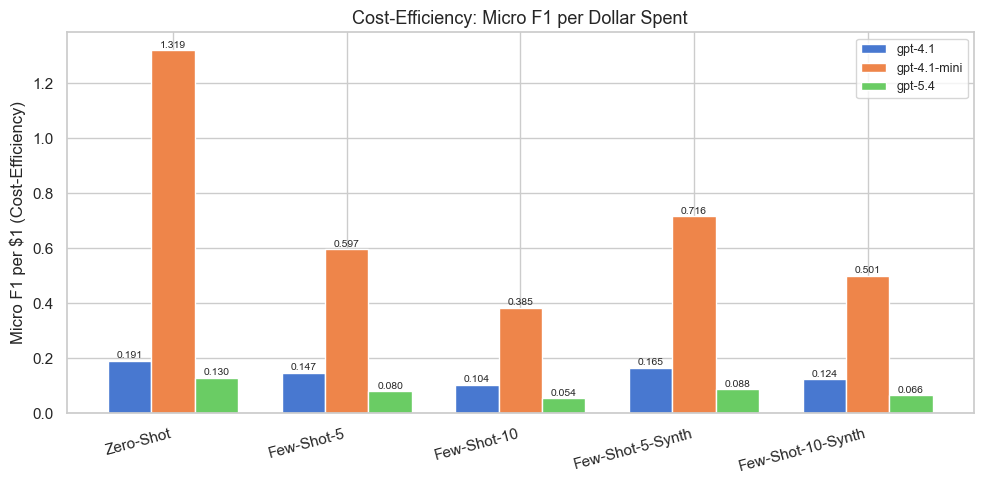

In [53]:
# --- Chart 2: Cost-Efficiency (Micro F1 per $1 spent) ---
fig, ax = plt.subplots(figsize=(10, 5))

for i, (model, color) in enumerate(zip(llm_models, colors)):
    sub = llm[llm["model"] == model].copy()
    sub = sub.set_index("mode").reindex(MODES)
    costs = cost_df[model].values
    efficiency = sub["micro_f1"].values / costs  # F1 per dollar

    bars = ax.bar(x + (i - 1) * width, efficiency, width, label=model, color=color)
    for bar, v in zip(bars, efficiency):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.002,
                f"{v:.3f}", ha="center", va="bottom", fontsize=7.5)

ax.set_xticks(x)
ax.set_xticklabels(MODE_LABELS, rotation=15, ha="right")
ax.set_ylabel("Micro F1 per $1 (Cost-Efficiency)")
ax.set_title("Cost-Efficiency: Micro F1 per Dollar Spent", fontsize=13)
ax.legend(loc="upper right", fontsize=9)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/cost_efficiency.png", dpi=150)
plt.show()

## 7. Qualitative Error Analysis — Label Conflation (gpt-4.1 Zero-Shot)

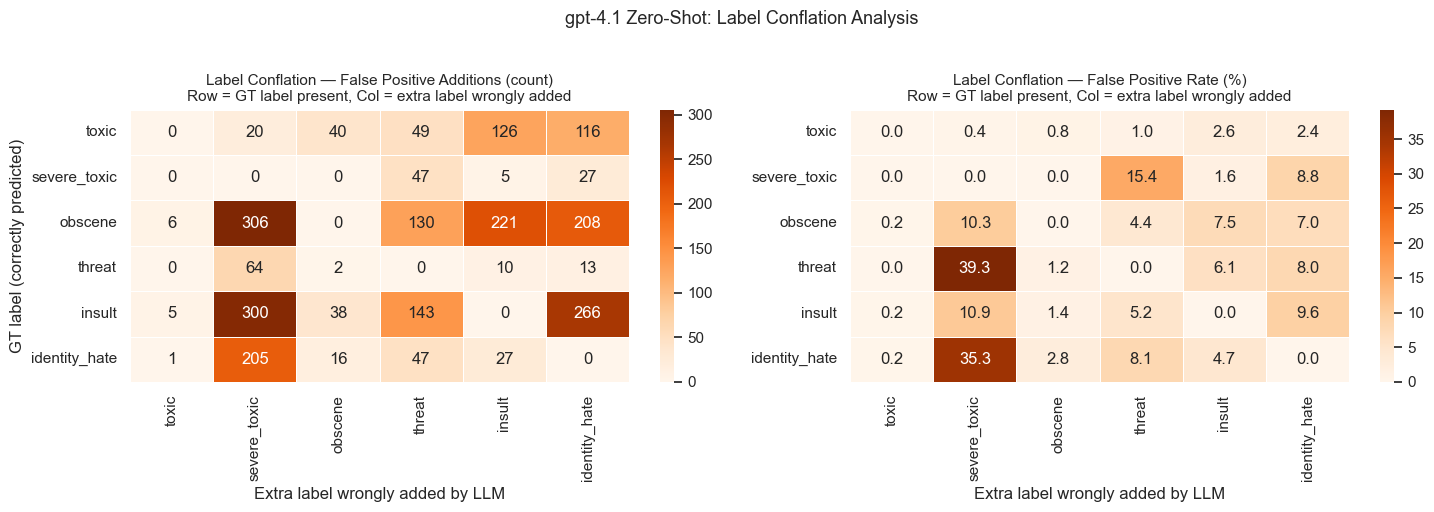


Top 10 conflation pairs (GT label → extra label wrongly added):


,GT label,Extra label added,count
13,obscene,severe_toxic,306
25,insult,severe_toxic,300
29,insult,identity_hate,266
16,obscene,insult,221
17,obscene,identity_hate,208
31,identity_hate,severe_toxic,205
27,insult,threat,143
15,obscene,threat,130
4,toxic,insult,126
5,toxic,identity_hate,116


In [56]:
gt   = pd.read_csv("data/test.csv").merge(
           pd.read_csv("data/test_labels.csv").query("toxic != -1"), on="id")
sample = pd.read_csv("results/sample.csv")
pred   = pd.read_csv("results/predictions_gpt-4.1_zero_shot.csv")

df = sample[["id"] + LABELS].merge(pred[["id"] + [f"pred_{l}" for l in LABELS]], on="id")
df = df.merge(gt[["id", "comment_text"]], on="id", how="left")

# ── Heatmap 1: Label Conflation (False Positive additions) ──────────────────
# Cell[i,j]: GT has label i but NOT j, yet LLM predicts both i AND j
# i.e., how often does the model "add" label j when it correctly spots label i?
fp_matrix = pd.DataFrame(0, index=LABELS, columns=LABELS)
for gt_label in LABELS:
    for fp_label in LABELS:
        if gt_label == fp_label:
            continue
        mask = (df[gt_label] == 1) & (df[fp_label] == 0) & \
               (df[f"pred_{gt_label}"] == 1) & (df[f"pred_{fp_label}"] == 1)
        fp_matrix.loc[gt_label, fp_label] = mask.sum()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Left: raw counts
sns.heatmap(fp_matrix, annot=True, fmt="d", cmap="Oranges",
            linewidths=0.5, ax=axes[0])
axes[0].set_title("Label Conflation — False Positive Additions (count)\n"
                  "Row = GT label present, Col = extra label wrongly added", fontsize=11)
axes[0].set_xlabel("Extra label wrongly added by LLM")
axes[0].set_ylabel("GT label (correctly predicted)")

# Right: normalised by GT count (rate)
gt_counts = df[LABELS].sum()
fp_rate = fp_matrix.div(gt_counts, axis=0) * 100  # % of GT-label rows affected
sns.heatmap(fp_rate, annot=True, fmt=".1f", cmap="Oranges",
            linewidths=0.5, ax=axes[1])
axes[1].set_title("Label Conflation — False Positive Rate (%)\n"
                  "Row = GT label present, Col = extra label wrongly added", fontsize=11)
axes[1].set_xlabel("Extra label wrongly added by LLM")
axes[1].set_ylabel("")

plt.suptitle("gpt-4.1 Zero-Shot: Label Conflation Analysis", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/label_conflation.png", dpi=150, bbox_inches="tight")
plt.show()

# Top 5 conflation pairs
pairs = fp_matrix.stack().reset_index()
pairs.columns = ["GT label", "Extra label added", "count"]
pairs = pairs[pairs["GT label"] != pairs["Extra label added"]].sort_values("count", ascending=False)
print("\nTop 10 conflation pairs (GT label → extra label wrongly added):")
pairs.head(10)

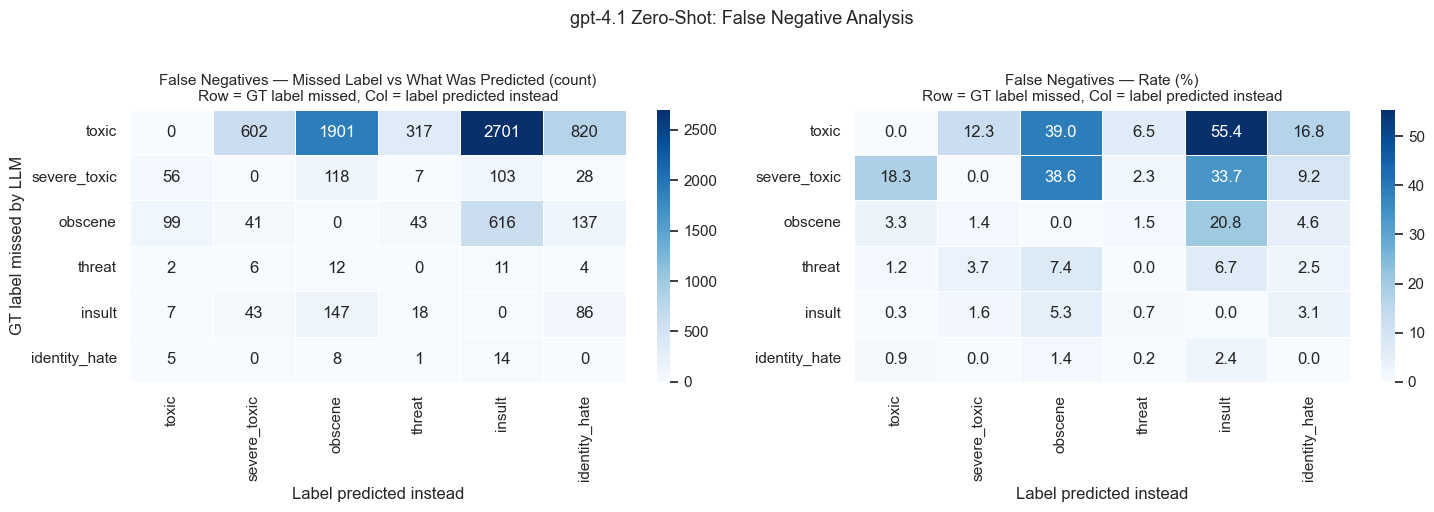


Top 10 false negative substitution pairs:


,GT label missed,Predicted instead,count
4,toxic,insult,2701
2,toxic,obscene,1901
5,toxic,identity_hate,820
16,obscene,insult,616
1,toxic,severe_toxic,602
3,toxic,threat,317
26,insult,obscene,147
17,obscene,identity_hate,137
8,severe_toxic,obscene,118
10,severe_toxic,insult,103


In [57]:
# ── Heatmap 2: False Negatives — what GT label does LLM miss, and what does it predict instead?
# Cell[i,j]: GT has label i (missed by LLM), and LLM predicts label j instead
fn_matrix = pd.DataFrame(0, index=LABELS, columns=LABELS)
for missed in LABELS:
    for predicted in LABELS:
        if missed == predicted:
            continue
        mask = (df[missed] == 1) & (df[f"pred_{missed}"] == 0) & \
               (df[f"pred_{predicted}"] == 1)
        fn_matrix.loc[missed, predicted] = mask.sum()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.heatmap(fn_matrix, annot=True, fmt="d", cmap="Blues",
            linewidths=0.5, ax=axes[0])
axes[0].set_title("False Negatives — Missed Label vs What Was Predicted (count)\n"
                  "Row = GT label missed, Col = label predicted instead", fontsize=11)
axes[0].set_xlabel("Label predicted instead")
axes[0].set_ylabel("GT label missed by LLM")

fn_rate = fn_matrix.div(gt_counts, axis=0) * 100
sns.heatmap(fn_rate, annot=True, fmt=".1f", cmap="Blues",
            linewidths=0.5, ax=axes[1])
axes[1].set_title("False Negatives — Rate (%)\n"
                  "Row = GT label missed, Col = label predicted instead", fontsize=11)
axes[1].set_xlabel("Label predicted instead")
axes[1].set_ylabel("")

plt.suptitle("gpt-4.1 Zero-Shot: False Negative Analysis", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/label_false_negatives.png", dpi=150, bbox_inches="tight")
plt.show()

pairs_fn = fn_matrix.stack().reset_index()
pairs_fn.columns = ["GT label missed", "Predicted instead", "count"]
pairs_fn = pairs_fn[pairs_fn["GT label missed"] != pairs_fn["Predicted instead"]].sort_values("count", ascending=False)
print("\nTop 10 false negative substitution pairs:")
pairs_fn.head(10)